<a href="https://colab.research.google.com/github/ismael-almazan/PNL/blob/main/Clasificacion_de_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Maestría en Inteligencia Artificial y Analítica de Datos<h1>
<h2>Procesamiento de Lenguaje Natural<h2>
<h2> Tarea: Clasificación de textos <h2>
<h3>Estudiante: Ismael Almazan Luna<h3>
Fecha : 24 de abril de 2026

Librerias requeridas

In [3]:
import pandas as pd
import re
import spacy
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [7]:
# Carga de datos desde Google Drive
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/PNL/IMDB Reviews.csv')

# Mostrar primeros datos
print(df.head())

                                              review  sentimento  \
0  One of the other reviewers has mentioned that ...           1   
1  A wonderful little production. <br /><br />The...           1   
2  I thought this was a wonderful way to spend ti...           1   
3  Basically there's a family where a little boy ...           0   
4  Petter Mattei's "Love in the Time of Money" is...           1   

                                             review0  
0  reviewer mention watch oz episode hook right e...  
1  wonderful little production br filming techniq...  
2  think wonderful way spend time hot summer week...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


# PREPROCESAMIENTO

In [ ]:
# Cargar modelo en_core_web_sm de spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])

# Funcion para preprocesamiento(Sotopword, lematizar, minusculas)
def preprocesar(textos):
    docs = nlp.pipe(
        textos,
        batch_size=1000,
        n_process=1
    )

    limpios = [
        " ".join(
            t.lemma_.lower()
            for t in doc
            if not t.is_stop and t.is_alpha
        )
        for doc in docs
    ]

    return limpios

df['review0'] = preprocesar(df['review'].astype(str))

# Guardar en Google Drive el resultado del proprocesamiento
df.to_csv('/content/drive/MyDrive/ClassFiles/PNL/IMDB Reviews.csv', index=False)

# Mostrar el registro 1 para comprobar
print(df.iloc[2])


review        I thought this was a wonderful way to spend ti...
sentimento                                                    1
review0       think wonderful way spend time hot summer week...
Name: 2, dtype: object


# ANALISIS EXPLORATORIO DE LOS DATOS

Cantidad de documentos:  50000
Valores duplicados:  424
Valores nulos:  0


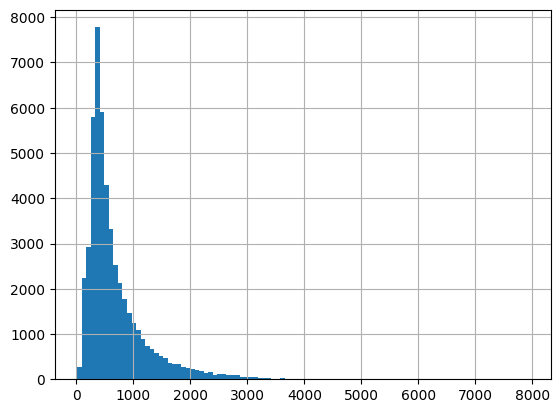

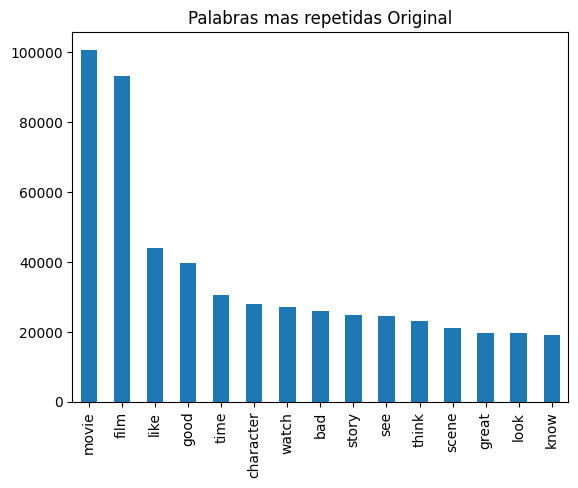

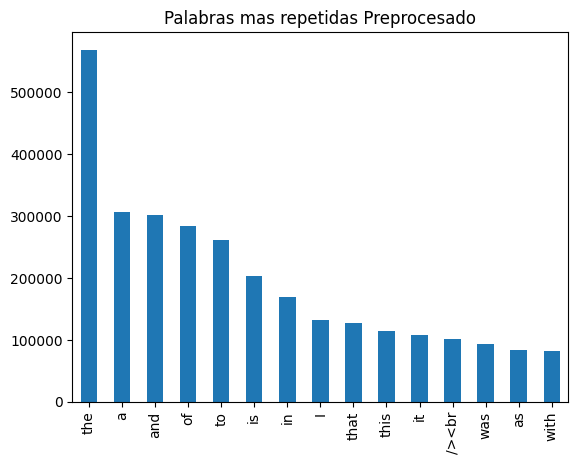

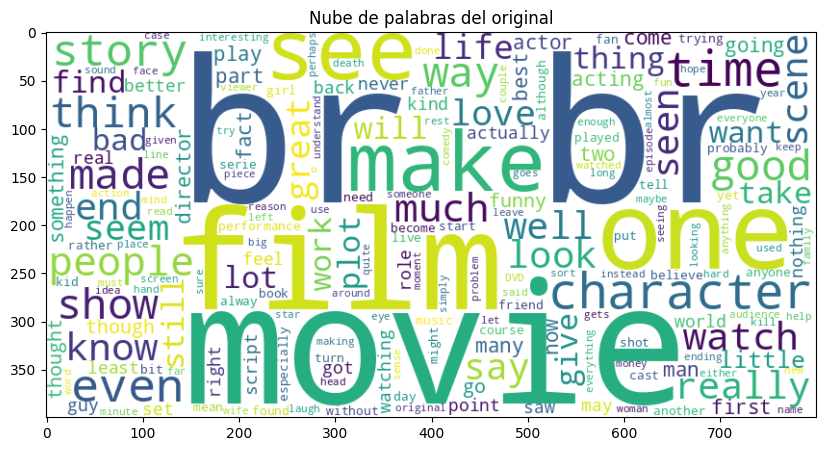

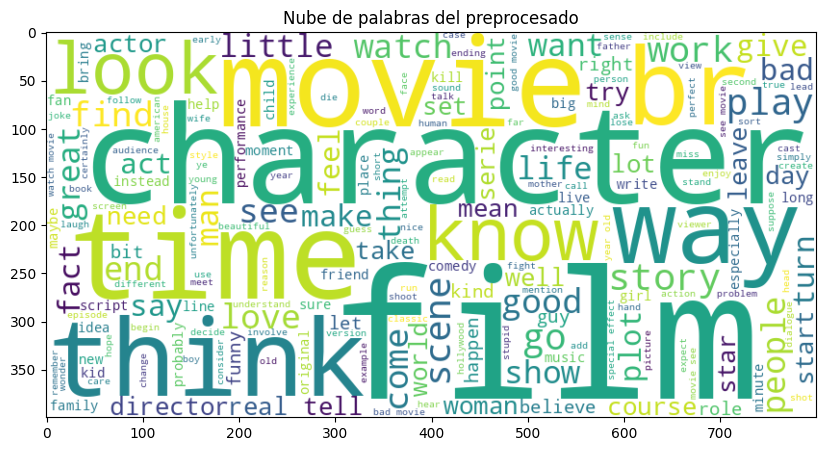

In [13]:
# Cantidad de documentos
print("Cantidad de documentos: ", len(df['review0']))

# Grafica df['sentimiento']
df['sentimento'].value_counts()

# Valores duplicados
print("Valores duplicados: ", df['review0'].duplicated().sum())

# Valores nulos
print("Valores nulos: ", df['review0'].isnull().sum())

# HIsograma con longitus de los documentos
df['review0'].str.len().hist(bins=100)
plt.show()

# Histograma de las 15 palabras mas repetidas
df['review0'].str.split(expand=True).stack().value_counts()[:15].plot(kind='bar')
plt.title('Palabras mas repetidas Original')
plt.show()

# Histograma de las 15 palabras mas repetidas
df['review'].str.split(expand=True).stack().value_counts()[:15].plot(kind='bar')
plt.title('Palabras mas repetidas Preprocesado')
plt.show()

# Nube de palabras del original
wordcloud = WordCloud(width=800, height=400
                      , background_color='white'
                      , min_font_size=10).generate(" ".join(df['review']))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Nube de palabras del original')
plt.axis
plt.show()

# Nube de palabras del preprocesado
wordcloud = WordCloud(width=800, height=400
                      , background_color='white'
                      , min_font_size=10).generate(" ".join(df['review0']))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Nube de palabras del preprocesado')
plt.axis
plt.show()



# VECTORIZACION

## TF-IDF

In [8]:
# Vectorizar con td idf y aplicar un preprocewsamiento adicional
tfidf = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2)
)

# Aplicar
X_tfidf = tfidf.fit_transform(df['review0'])
print(X_tfidf)
X_tfidf.shape

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3430799 stored elements and shape (50000, 5000)>
  Coords	Values
  (0, 3754)	0.0763914275452319
  (0, 2794)	0.05936438538128993
  (0, 4839)	0.09168940862458977
  (0, 3224)	0.6044963945386296
  (0, 1392)	0.12027021938254166
  (0, 2124)	0.08464963368728162
  (0, 3769)	0.09632214812035071
  (0, 1428)	0.06530958065388288
  (0, 2014)	0.04820690714013579
  (0, 4474)	0.036745125767737724
  (0, 4288)	0.15502549076851668
  (0, 3898)	0.035428140196259277
  (0, 4773)	0.2659376069101283
  (0, 3979)	0.04818532131605146
  (0, 4937)	0.056727162618779164
  (0, 4628)	0.08051417891769289
  (0, 2048)	0.0888574658161974
  (0, 3544)	0.06615322319041733
  (0, 3548)	0.08444035357220524
  (0, 3669)	0.08371572903940576
  (0, 1258)	0.07081398714632721
  (0, 3987)	0.06067988214006325
  (0, 2023)	0.0978924404113189
  (0, 748)	0.05590980726914248
  (0, 4721)	0.05351608239927466
  :	:
  (49999, 4687)	0.10677706629342314
  (49999, 2291)	0.1701885650786801

(50000, 5000)

## Bag of Word

In [9]:
# Vectorizar con bow y aplicar un preprocewsamiento adicional
bow = CountVectorizer(
    stop_words='english',
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2)
)

# Aplicar
X_bow = bow.fit_transform(df['review0'])
print(X_bow)
X_bow.shape

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3430799 stored elements and shape (50000, 5000)>
  Coords	Values
  (0, 3754)	1
  (0, 2794)	1
  (0, 4839)	3
  (0, 3224)	6
  (0, 1392)	2
  (0, 2124)	1
  (0, 3769)	2
  (0, 1428)	1
  (0, 2014)	1
  (0, 4474)	1
  (0, 4288)	2
  (0, 3898)	1
  (0, 4773)	4
  (0, 3979)	1
  (0, 4937)	1
  (0, 4628)	1
  (0, 2048)	1
  (0, 3544)	1
  (0, 3548)	1
  (0, 3669)	1
  (0, 1258)	1
  (0, 3987)	1
  (0, 2023)	1
  (0, 748)	1
  (0, 4721)	1
  :	:
  (49999, 4687)	1
  (49999, 2291)	1
  (49999, 287)	1
  (49999, 2024)	1
  (49999, 3704)	1
  (49999, 2212)	1
  (49999, 3885)	1
  (49999, 232)	1
  (49999, 3004)	1
  (49999, 4952)	1
  (49999, 3705)	1
  (49999, 4605)	1
  (49999, 2434)	1
  (49999, 4188)	1
  (49999, 4216)	1
  (49999, 576)	1
  (49999, 2443)	1
  (49999, 3010)	1
  (49999, 666)	1
  (49999, 3002)	1
  (49999, 1920)	1
  (49999, 1461)	1
  (49999, 3706)	1
  (49999, 1895)	1
  (49999, 1534)	1


(50000, 5000)

# PARTICION DEL CONJUNTO DE DATOS
•	Utiliza una partición (train_test_split) 80-20 para los conjuntos train y test.

In [10]:
# Particionar el conjunto de datos
#para BOw
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, df['sentimento'], test_size=0.2, random_state=42)

#para TF-IDF
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, df['sentimento'], test_size=0.2, random_state=42)

# ENTRENAMIENTO NODELOS

Entrenar los modelos Multinomial Naive Bayes, SVM, Random Forest, kNN y Logistic Regression

Por el tiempo de entrenaiento de los modelos es conveniente guardar los modelos en drive

In [15]:
# CON BOW----------------------------------------------------------------------

#Modelo Multinomia Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train_bow, y_train_bow)

#Modelo SVM
svm = SVC()
svm.fit(X_train_bow, y_train_bow)

#Modelo Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_bow, y_train_bow)

#Modelo kNN
knn = KNeighborsClassifier()
knn.fit(X_train_bow, y_train_bow)

#Modelo Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bow, y_train_bow)

# Guardar modelos ya entrenados
joblib.dump(mnb, '/content/drive/MyDrive/ClassFiles/PNL/mnb.pkl')
joblib.dump(svm, '/content/drive/MyDrive/ClassFiles/PNL/svm.pkl')
joblib.dump(rf, '/content/drive/MyDrive/ClassFiles/PNL/rf.pkl')
joblib.dump(knn, '/content/drive/MyDrive/ClassFiles/PNL/knn.pkl')
joblib.dump(lr, '/content/drive/MyDrive/ClassFiles/PNL/lr.pkl')

# volver a cargar los modelos ya entrenados
mnb = joblib.load('/content/drive/MyDrive/ClassFiles/PNL/mnb.pkl')
svm = joblib.load('/content/drive/MyDrive/ClassFiles/PNL/svm.pkl')
rf = joblib.load('/content/drive/MyDrive/ClassFiles/PNL/rf.pkl')
knn = joblib.load('/content/drive/MyDrive/ClassFiles/PNL/knn.pkl')
lr = joblib.load('/content/drive/MyDrive/ClassFiles/PNL/lr.pkl')



# CON TF-IDF-------------------------------------------------------------------

# Modelo Multinomial Naive Bayes
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Modelo SVM
svm_tfidf = SVC()
svm_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Modelo Random Forest
rf_tfidf = RandomForestClassifier()
rf_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Modelo kNN
knn_tfidf = KNeighborsClassifier()
knn_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Modelo Logistic Regression
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Guardar modelos ya entrenados
path = '/content/drive/MyDrive/ClassFiles/PNL/'

joblib.dump(mnb_tfidf, path + 'mnb_tfidf.pkl')
joblib.dump(svm_tfidf, path + 'svm_tfidf.pkl')
joblib.dump(rf_tfidf, path + 'rf_tfidf.pkl')
joblib.dump(knn_tfidf, path + 'knn_tfidf.pkl')
joblib.dump(lr_tfidf, path + 'lr_tfidf.pkl')


# volver a cargar los modelos ya entrenados
mnb_tfidf = joblib.load(path + 'mnb_tfidf.pkl')
svm_tfidf = joblib.load(path + 'svm_tfidf.pkl')
rf_tfidf = joblib.load(path + 'rf_tfidf.pkl')
knn_tfidf = joblib.load(path + 'knn_tfidf.pkl')
lr_tfidf = joblib.load(path + 'lr_tfidf.pkl')

# MATRIZ DE CONFUSION
•	Mostrar la matriz de confusión.

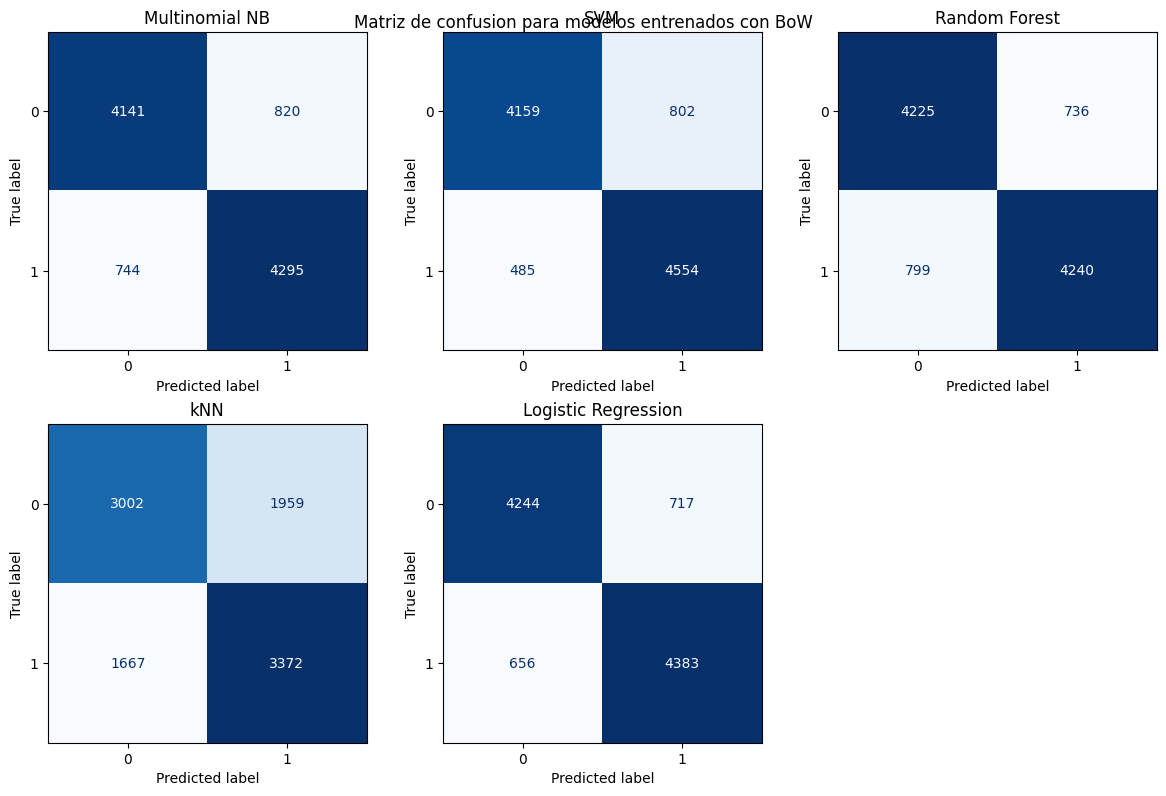

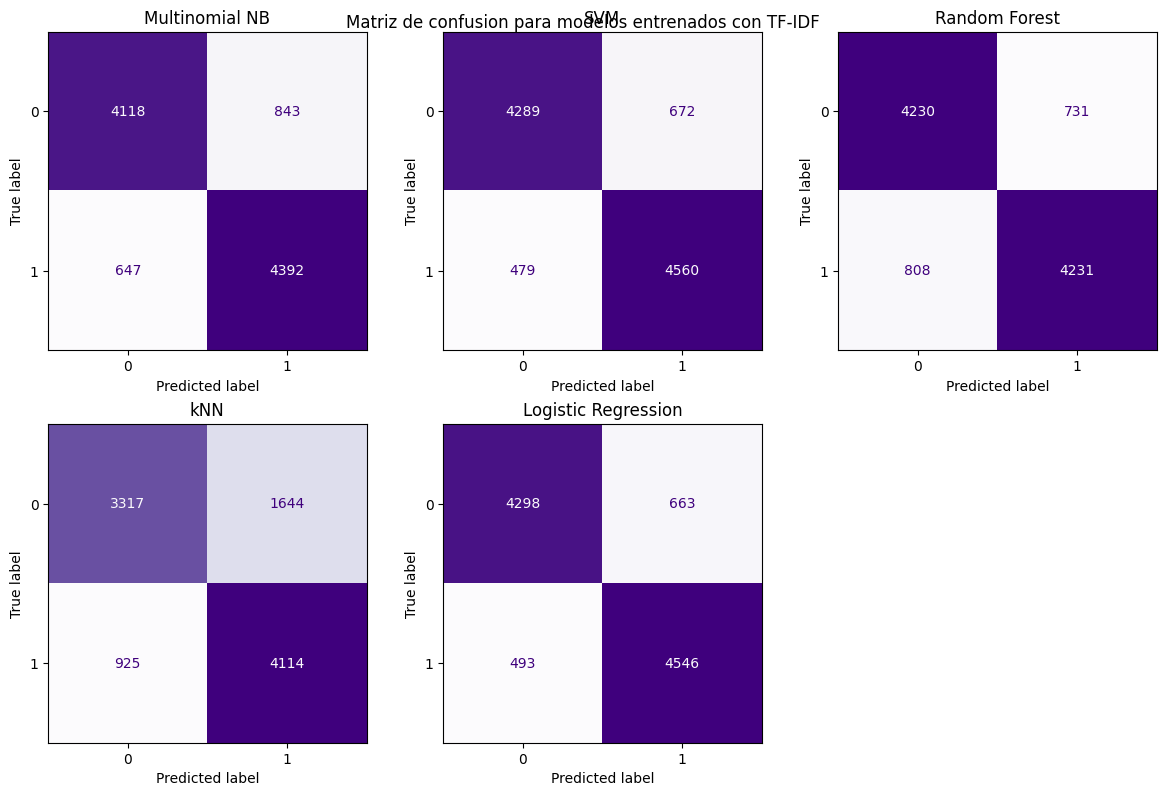

In [19]:
modelos = [
    (mnb, "Multinomial NB"),
    (svm, "SVM"),
    (rf, "Random Forest"),
    (knn, "kNN"),
    (lr, "Logistic Regression")
]

# Graficar todo junto para bow------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes = axes.flatten()

for i, (modelo, nombre) in enumerate(modelos):
    y_pred = modelo.predict(X_test_bow)

    cm = confusion_matrix(y_test_bow, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nombre)

fig.delaxes(axes[5])

plt.tight_layout()
#Titulo del grafico
fig.suptitle('Matriz de confusion para modelos entrenados con BoW')
plt.show()

# Graficar todo junto para tfodf------------------------------------------------
modelos_tfidf = [
    (mnb_tfidf, "Multinomial NB"),
    (svm_tfidf, "SVM"),
    (rf_tfidf, "Random Forest"),
    (knn_tfidf, "kNN"),
    (lr_tfidf, "Logistic Regression")
]


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes = axes.flatten()

for i, (modelo, nombre) in enumerate(modelos_tfidf):
    y_pred = modelo.predict(X_test_tfidf)

    cm = confusion_matrix(y_test_tfidf, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Purples', colorbar=False)
    axes[i].set_title(nombre)


fig.delaxes(axes[5])

plt.tight_layout()
fig.suptitle('Matriz de confusion para modelos entrenados con TF-IDF')
plt.show()

# METRICAS

Aplicar las métricas Precision, Recall, F1-Score (por cada una de las clases), Accuracy y AUC-ROC.

In [20]:
# Genarar los resultado ya resumido en tablas
def generar_tabla_metricas(modelos, X_test, y_test):
    data = []
    labels = sorted(y_test.unique())

    for modelo, nombre in modelos:
        y_pred = modelo.predict(X_test)

        if hasattr(modelo, "predict_proba"):
            y_prob = modelo.predict_proba(X_test)[:, 1]
        else:
            y_prob = modelo.decision_function(X_test)

        report = classification_report(y_test, y_pred, output_dict=True)
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        l1, l2 = str(labels[0]), str(labels[1])

        data.append({
            'Modelo': nombre,
            'C0_Precision': report[l1]['precision'],
            'C0_Recall': report[l1]['recall'],
            'C0_F1-Score': report[l1]['f1-score'],
            'C1_Precision': report[l2]['precision'],
            'C1_Recall': report[l2]['recall'],
            'C1_F1-Score': report[l2]['f1-score'],
            'Accuracy': acc,
            'AUC-ROC': auc
        })

    df_result = pd.DataFrame(data)
    df_result.columns = [
        'Modelo',
        'Precision (C0)', 'Recall (C0)', 'F1-Score (C0)',
        'Precision (C1)', 'Recall (C1)', 'F1-Score (C1)',
        'Accuracy', 'AUC-ROC'
    ]
    return df_result

# para BoW
modelos_bow_lista = [(mnb, "Naive Bayes"), (svm, "SVM"), (rf, "Random Forest"), (knn, "kNN"), (lr, "Logistic Regression")]
tabla_bow = generar_tabla_metricas(modelos_bow_lista, X_test_bow, y_test_bow)

# para TF-IDF
modelos_tfidf_lista = [(mnb_tfidf, "Naive Bayes"), (svm_tfidf, "SVM"), (rf_tfidf, "Random Forest"), (knn_tfidf, "kNN"), (lr_tfidf, "Logistic Regression")]
tabla_tfidf = generar_tabla_metricas(modelos_tfidf_lista, X_test_tfidf, y_test_tfidf)

# Mostrar resultados
print("TABLA UTILIZANDO BAG OF WORDS")
display(tabla_bow)

print("\nTABLA UTILIZANDO TF-IDF")
display(tabla_tfidf)



TABLA UTILIZANDO BAG OF WORDS


,Modelo,Precision (C0),Recall (C0),F1-Score (C0),Precision (C1),Recall (C1),F1-Score (C1),Accuracy,AUC-ROC
0,Naive Bayes,0.847697,0.834711,0.841154,0.839687,0.852352,0.845972,0.8436,0.913160
1,SVM,0.895564,0.838339,0.866007,0.850261,0.903751,0.876190,0.8713,0.945428
2,Random Forest,0.840963,0.851643,0.846269,0.852090,0.841437,0.846730,0.8465,0.921325
3,kNN,0.642964,0.605120,0.623468,0.632527,0.669180,0.650338,0.6374,0.685069
4,Logistic Regression,0.866122,0.855473,0.860765,0.859412,0.869815,0.864582,0.8627,0.937297



TABLA UTILIZANDO TF-IDF


,Modelo,Precision (C0),Recall (C0),F1-Score (C0),Precision (C1),Recall (C1),F1-Score (C1),Accuracy,AUC-ROC
0,Naive Bayes,0.864218,0.830075,0.846802,0.838968,0.871602,0.854974,0.8510,0.927684
1,SVM,0.899539,0.864543,0.881694,0.871560,0.904941,0.887937,0.8849,0.956326
2,Random Forest,0.839619,0.852651,0.846085,0.852680,0.839651,0.846115,0.8461,0.925037
3,kNN,0.781942,0.668615,0.720852,0.714484,0.816432,0.762064,0.7431,0.812221
4,Logistic Regression,0.897099,0.866358,0.881460,0.872720,0.902163,0.887198,0.8844,0.953427


# RESULTADOS Y CONCLUSION

Analiza y compara los resultados para responder lo siguiente:

*	¿Cuál fue el mejor modelo en cada una de las tablas? Justifica tus respuestas en base a las métricas obtenidas.
*	¿En qué estrategia funcionaron mejor los algoritmos de clasificación, en Bag of Words o en TF-IDF?
